In [1]:
import re
import unicodedata
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer

PROCESSED_DIR = Path("../data/processed")
vagas = pd.read_parquet(PROCESSED_DIR / "vagas_limpas.parquet")

AZUL, TINTA, MUTED = "#2a78d6", "#0b0b0b", "#898781"
plt.rcParams.update({
    "figure.facecolor": "#fcfcfb",
    "axes.facecolor": "#fcfcfb",
    "axes.edgecolor": "#c3c2b7",
    "axes.labelcolor": "#52514e",
    "axes.titlecolor": TINTA,
    "axes.titlelocation": "left",
    "axes.grid": True,
    "grid.color": "#e1e0d9",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "xtick.color": MUTED,
    "ytick.color": MUTED,
    "ytick.labelcolor": "#52514e",
    "figure.dpi": 110,
})


def barras_h(serie, titulo, xlabel="", fmt="{:.0f}"):
    serie = serie.sort_values()
    fig, ax = plt.subplots(figsize=(8, 0.42 * len(serie) + 1))
    ax.barh(serie.index, serie.values, color=AZUL, height=0.62)
    for i, v in enumerate(serie.values):
        ax.text(v + serie.max() * 0.015, i, fmt.format(v), va="center", color="#52514e", fontsize=9)
    ax.set_title(titulo)
    ax.set_xlabel(xlabel)
    ax.grid(axis="y", visible=False)
    ax.margins(x=0.09)
    fig.tight_layout()
    plt.show()


print(f"{len(vagas)} vagas · idiomas: {vagas['idioma'].value_counts().to_dict()}")

283 vagas · idiomas: {'pt': 167, 'en': 116}


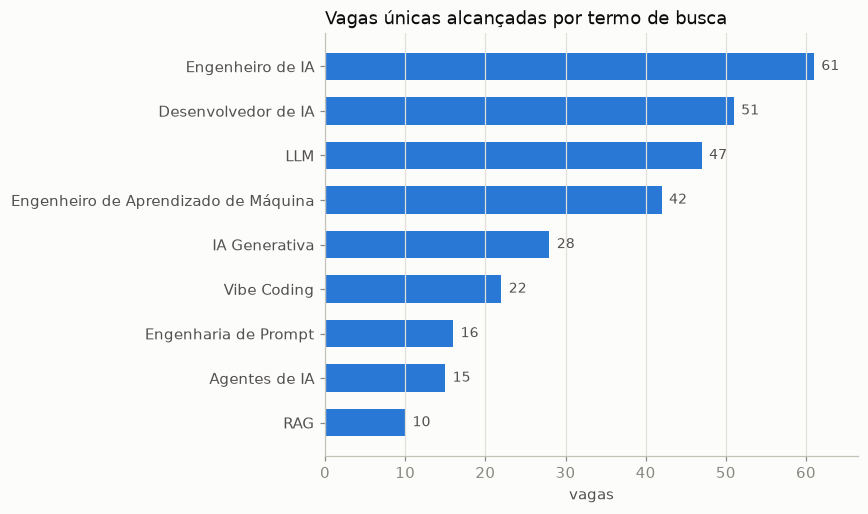

In [2]:
por_termo = vagas.explode("search_keywords")["search_keywords"].value_counts()
barras_h(por_termo, "Vagas únicas alcançadas por termo de busca", "vagas")

In [3]:
multi = vagas[vagas["search_keywords"].str.len() > 1]
print(f"{len(multi)} de {len(vagas)} vagas ({len(multi) / len(vagas):.1%}) foram encontradas por mais de um termo:")
multi[["job_title", "company", "search_keywords"]]

6 de 283 vagas (2.1%) foram encontradas por mais de um termo:


,job_title,company,search_keywords
13,Lead AI Engineer — Productivity Systems,Nubank,"[Agentes de IA, Engenharia de Prompt]"
99,AI Engineer - Remote Work,BairesDev,"[Engenheiro de Aprendizado de Máquina, Engenhe..."
110,AI Machine Learning Engineer - Remote - Latin ...,FullStack,"[Engenheiro de Aprendizado de Máquina, LLM]"
121,Engenheiro (a) de IA - Pleno 1,EY,"[Engenheiro de Aprendizado de Máquina, Engenhe..."
136,Engenheiro (a) de IA - Pleno,EY,"[Engenheiro de IA, LLM, RAG]"
170,Pipeline - Engenheiro de IA - Pleno,EY,"[Engenheiro de IA, LLM, RAG]"


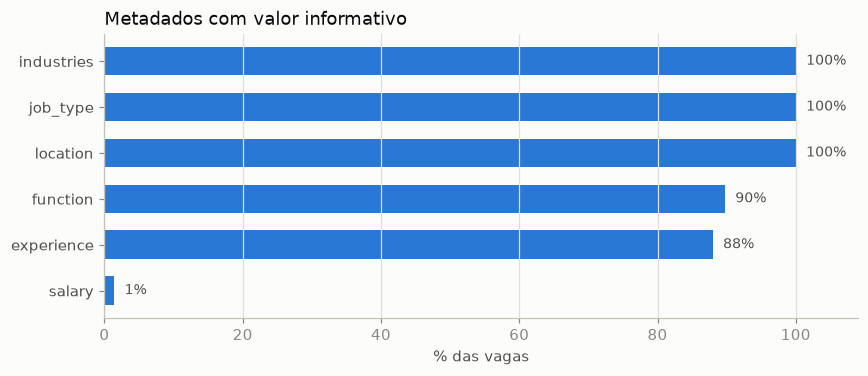

In [4]:
SENTINELAS = {"not_described", "Não aplicável", "Outro"}

meta = ["location", "experience", "job_type", "function", "industries", "salary"]
informativos = (vagas[meta].notna() & ~vagas[meta].isin(SENTINELAS)).mean() * 100
barras_h(informativos, "Metadados com valor informativo", "% das vagas", fmt="{:.0f}%")

In [5]:
for coluna in ["experience", "job_type"]:
    print(vagas[coluna].value_counts().head(8).to_string(), "\n")
print(vagas["location"].value_counts().head(10).to_string())

experience
Pleno-sênior     173
Assistente        67
Não aplicável     34
Júnior             4
Executivo          3
Diretor            2 

job_type
Tempo integral    279
Contrato            3
Estágio             1 

location
Brasil                     88
São Paulo, SP              72
Rio de Janeiro e Região    11
Curitiba, PR                8
São Paulo, Brasil           8
Manaus, AM                  6
Belo Horizonte, MG          5
Minas Gerais, Brasil        5
Brasília, DF                4
Florianópolis, SC           4


In [6]:
import nltk

nltk.download("stopwords", quiet=True)
from nltk.corpus import stopwords


def normalizar(texto):
    texto = unicodedata.normalize("NFKD", texto.lower())
    texto = "".join(c for c in texto if not unicodedata.combining(c))
    texto = re.sub(r"[^a-z0-9\s\+\#\.]", " ", texto)
    texto = re.sub(r"\.(?![a-z0-9])", " ", texto)
    return re.sub(r"\s+", " ", texto).strip()


base_skills = vagas["secao_requisitos"].where(vagas["secao_requisitos"] != "", vagas["descricao"]).map(normalizar)

GENERICAS = {"experiencia", "conhecimento", "conhecimentos", "vivencia", "capacidade", "requisitos",
             "vaga", "atuacao", "atuar", "area", "areas", "anos", "informacoes", "adicionais",
             "experience", "knowledge", "skills", "ability", "years", "strong", "solid", "plus",
             "work", "working", "hands", "including", "looking"}
STOP = sorted(
    {normalizar(w) for w in stopwords.words("portuguese") + stopwords.words("english")} | GENERICAS
)


def top_ngramas(textos, stop, n, k=15):
    cv = CountVectorizer(ngram_range=(n, n), stop_words=stop, token_pattern=r"[a-z\.\#\+][a-z0-9\+\#\.]+")
    contagem = cv.fit_transform(textos).sum(axis=0).A1
    return pd.Series(contagem, index=cv.get_feature_names_out()).nlargest(k)

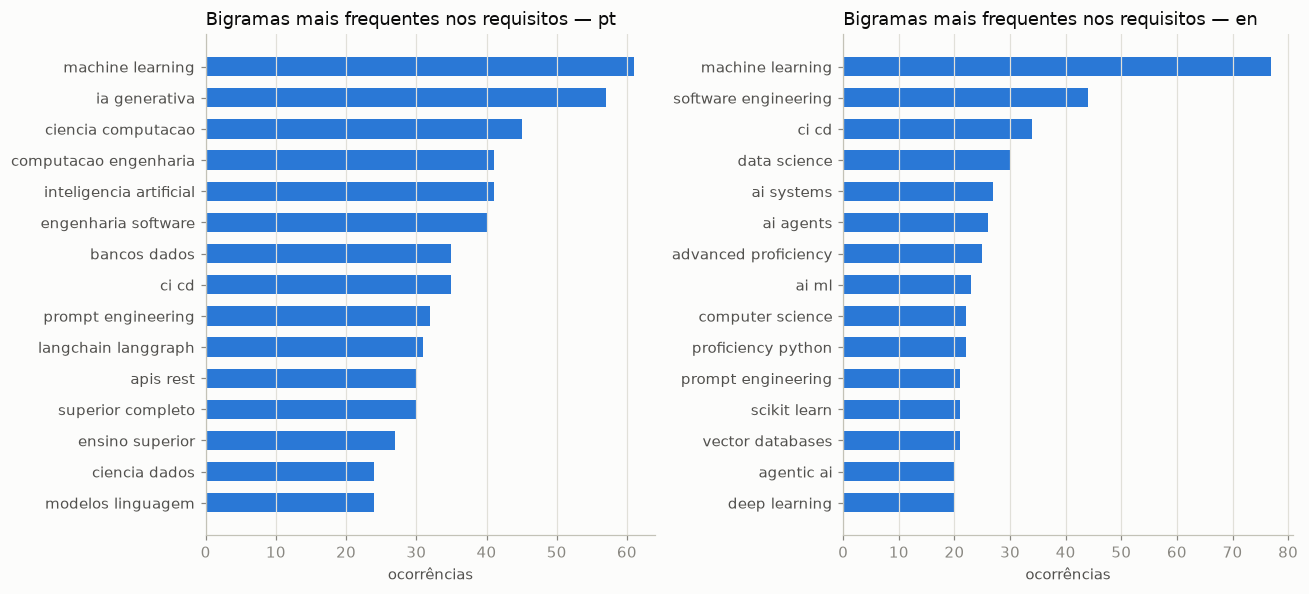

In [7]:
fig, eixos = plt.subplots(1, 2, figsize=(12, 5.5))
for ax, idioma in zip(eixos, ["pt", "en"]):
    top = top_ngramas(base_skills[vagas["idioma"] == idioma], STOP, 2)[::-1]
    ax.barh(top.index, top.values, color=AZUL, height=0.62)
    ax.set_title(f"Bigramas mais frequentes nos requisitos — {idioma}")
    ax.set_xlabel("ocorrências")
    ax.grid(axis="y", visible=False)
fig.tight_layout()
plt.show()

In [8]:
pd.DataFrame({
    idioma: top_ngramas(base_skills[vagas["idioma"] == idioma], STOP, 1, 20).index
    for idioma in ["pt", "en"]
})

,pt,en
0,ia,ai
1,dados,data
2,desenvolvimento,engineering
3,modelos,systems
4,engenharia,learning
5,sistemas,production
6,python,building
7,agentes,python
8,apis,ml
9,solucoes,frameworks


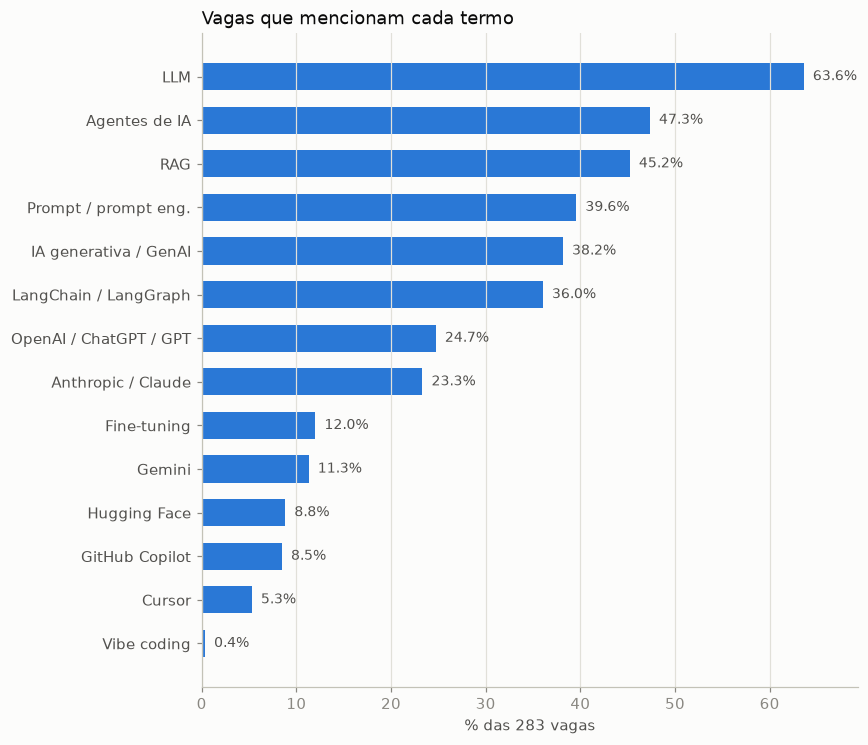

In [9]:
TERMOS_IA = {
    "LLM": r"\bllms?\b|large language model",
    "IA generativa / GenAI": r"ia generativa|generative ai|\bgen ?ai\b",
    "Prompt / prompt eng.": r"prompt",
    "RAG": r"\brag\b|retrieval augmented",
    "Agentes de IA": r"agentes? (?:de ia|inteligentes|autonomos)|ai agents?|agentic|multi agent",
    "Fine-tuning": r"fine tun|ajuste fino",
    "Vibe coding": r"vibe coding",
    "GitHub Copilot": r"copilot",
    "Cursor": r"\bcursor\b",
    "OpenAI / ChatGPT / GPT": r"openai|chatgpt|\bgpt\b",
    "Anthropic / Claude": r"anthropic|\bclaude\b",
    "Gemini": r"\bgemini\b",
    "LangChain / LangGraph": r"langchain|langgraph",
    "Hugging Face": r"hugging ?face",
}

mencoes = pd.Series({
    nome: vagas["descricao_norm"].str.contains(padrao).mean() * 100
    for nome, padrao in TERMOS_IA.items()
})
barras_h(mencoes, "Vagas que mencionam cada termo", f"% das {len(vagas)} vagas", fmt="{:.1f}%")

In [10]:
titulo_norm = vagas["job_title"].map(normalizar)
com_vibe = vagas[vagas["descricao_norm"].str.contains("vibe cod") | titulo_norm.str.contains("vibe cod")]
print(f"{len(com_vibe)} vagas mencionam 'vibe coding' no título ou na descrição\n")
print("Termos de busca que as encontraram:")
print(com_vibe.explode("search_keywords")["search_keywords"].value_counts().to_string())
com_vibe[["job_title", "company", "idioma", "search_keywords"]]

1 vagas mencionam 'vibe coding' no título ou na descrição

Termos de busca que as encontraram:
search_keywords
Agentes de IA    1


,job_title,company,idioma,search_keywords
5,Vibe Coder,Darwin AI,en,[Agentes de IA]


In [11]:
linhas = []
for idioma in ["pt", "en"]:
    textos = base_skills[vagas["idioma"] == idioma]
    for n in (1, 2):
        top = top_ngramas(textos, STOP, n, 50)
        linhas.append(pd.DataFrame({"idioma": idioma, "n": n, "termo": top.index, "frequencia": top.values}))

ngramas = pd.concat(linhas, ignore_index=True)
ngramas.to_csv(PROCESSED_DIR / "ngramas_requisitos.csv", index=False)
print(f"{len(ngramas)} n-gramas salvos em {PROCESSED_DIR / 'ngramas_requisitos.csv'}")

200 n-gramas salvos em ..\data\processed\ngramas_requisitos.csv
